## 特征值与特征向量


### PCA(主成分分析，Principal Component Analysis):
 - 定义
    > 在一堆数据中,找到**变化最大**的几个方向用,用**更低**的维度去表示它
 - 基本流程
    > 原始数据=>数据中心化=>计算协方差矩阵=>求特征值,特征向量=>按照特征值大小排序=>选择最大的几个特征值对应的特征向量=>数据投影=>降维后的数据
    $$
    X
    \rightarrow
    X'=X-\mu
    \rightarrow
    \Sigma=\frac{1}{n-1}X'^TX'
    \rightarrow
    \Sigma v=\lambda v
    \rightarrow
    W
    \rightarrow
    Z=X'W
    $$
- 阶段要点
    - 数据中心化 :不用关心数据的具体形状,着眼于数值的**偏离程度**
    $$
            X' = X-\mu
    $$
        - $\mu$:平均值
    - 计算协方差矩阵
    $$
    \Sigma=\frac{1}{n-1}{X'}^TX'
    $$
    - 求特征值,特征向量
    $$
    \boxed{\Sigma\mathbf v=\lambda\mathbf v}
    $$

        这就和前面学习的特征值问题完全一样：

        - $\mathbf v$：特征向量，对应数据的主要变化方向
        - $\lambda$：特征值，表示数据沿该方向的变化程度
    - 数据投影
        PCA 找到前 $k$ 个主成分方向后，将原始数据投影到这些方向上。

        假设：

        $$
        X'\in\mathbb{R}^{n\times m}
        $$

        选取前 $k$ 个特征向量：

        $$
        W\in\mathbb{R}^{m\times k}
        $$

        将数据投影到主成分方向：

        $$
        Z=X'W
        $$

        得到：

        $$
        Z\in\mathbb{R}^{n\times k}
        $$

        其中：

        - $X'$：中心化后的原始数据
        - $W$：选取的前 $k$ 个特征向量
        - $Z$：投影后的数据
        - $n$：样本数量
        - $m$：原始特征数量
        - $k$：降维后的特征数量

        因此：

        $$
        n\times m
        \quad\times\quad
        m\times k
        \quad=\quad
        n\times k
        $$
        > **把原来 $m$ 维的数据，投影到前 $k$ 个最重要的主成分方向上，从而将 $m$ 维数据降到 $k$ 维。**

- 疑问点
  1. 为啥是n-1不是n?
        > 因为n个数据样本是从总量数据中抽取出来的,当前面n-1个数据值已经确认,第n个也就确认了,样本本身的均值已经消耗了一个变量值
  2. 为啥使用X'和 X'^T相乘,而不是直接使用X'?
        > 本质在计算不同特征向量之间的内积
        - 对角线方向特征**自身**的变化程度
        - 非对角线方向**两个特征之间**共同变化程度
        - 值大于0,倾向于**同方向**变化,值小于0倾向于**反方向**变化,约等于0表示两个特征相关性较弱
  3. 矩阵的维度变化?(最终为方阵)?

        先看：
        $$
        X'^T
        $$

        如果：

        $$
        X'\in\mathbb{R}^{n\times m}
        $$

        那么转置后：

        $$
        X'^T\in\mathbb{R}^{m\times n}
        $$

        因此：

        $$
        X'^TX'
        \in
        \mathbb{R}^{m\times m}
        $$

        刚好得到一个：

        > **特征 × 特征的矩阵**
  4. 为啥协方差矩阵一定存在完整的特征值和特征向量?

        因为：
        $$
        (X'^TX')^T=X'^TX'
        $$
        所以：
        $$
        \boxed{\Sigma^T=\Sigma}
        $$
        > **实对称矩阵的特征值全部是实数，并且一定可以找到一组正交的特征向量**





## 课堂任务:
### 1. 会求解特征值和特征向量?
      1. 手写计算3*3的特征值和特征向量

### 2. 验证一些理论比如说矩阵的轨迹等于特征值之和,行列式等于特征值之积?
   - 矩阵的轨迹:矩阵**主对角线**上所有元素的**和**

| 矩阵量                            | 计算方式     | 特征值对应关系 |
|-----------------------------------| -------- | ------- |
| **轨迹** $(\operatorname{tr}(A))$ | 主对角线元素之和 | 特征值之和   |
| **行列式** $(\det(A))$            | 行列式计算    | 特征值之积   |




In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

print("success")

In [2]:
A = np.array([[2.0, 1.0, 3.0],
              [7.0, 2.0, 1.0],
              [10.0, 1.0, 2.0]
              ])
# 轨迹
tr = np.trace(A)
# 行列式
det = np.linalg.det(A)
# 特征值与特征向量
w, V = np.linalg.eig(A)

# 验证
print('轨迹等于特征值之和:', np.isclose(tr, np.sum(w)))
print('行列式等于特征值积:', np.isclose(det, np.prod(w)))


轨迹等于特征值之和: True
行列式等于特征值积: True


### 3. 对称矩阵：验证特征向量互相正交

### 推导证明

#### 1. 前提

设 $A$ 是一个实对称矩阵，满足：

$$
\boxed{A^T=A}
$$

设 $v_1$、$v_2$ 是 $A$ 的两个特征向量：

$$
\boxed{Av_1=\lambda_1v_1}
$$

$$
\boxed{Av_2=\lambda_2v_2}
$$

并且两个特征值不同：

$$
\boxed{\lambda_1\ne\lambda_2}
$$

---

#### 2. 需要证明

证明两个特征向量互相正交：

$$
\boxed{v_1^Tv_2=0}
$$

因为两个向量的内积为 $0$，所以：

$$
\boxed{v_1\perp v_2}
$$

---

#### 3. 依赖的性质

##### 3.1 内积交换律

对于两个实向量：

$$
\boxed{v_1^Tv_2=v_2^Tv_1}
$$

原因是：

$$
v_1^Tv_2
=
\sum_{i=1}^{n}v_{1i}v_{2i}
$$

而实数乘法满足交换律：

$$
v_{1i}v_{2i}
=
v_{2i}v_{1i}
$$

因此：

$$
\boxed{v_1^Tv_2=v_2^Tv_1}
$$

##### 3.2 对称矩阵

$$
\boxed{A^T=A}
$$

##### 3.3 特征向量定义

如果 $v$ 是矩阵 $A$ 的特征向量，对应特征值 $\lambda$，那么：

$$
\boxed{Av=\lambda v}
$$

因此：

$$
Av_1=\lambda_1v_1
$$

$$
Av_2=\lambda_2v_2
$$

---

## 4. 推导步骤

### 第 1 步：从第一个特征方程开始

已知：

$$
Av_1=\lambda_1v_1
$$

在等式两边左乘 $v_2^T$：

$$
v_2^TAv_1
=
v_2^T\lambda_1v_1
$$

因为 $\lambda_1$ 是一个标量，可以移到前面：

$$
\boxed{
v_2^TAv_1
=
\lambda_1v_2^Tv_1
}
$$

---

### 第 2 步：从第二个特征方程开始

已知：

$$
Av_2=\lambda_2v_2
$$

在等式两边左乘 $v_1^T$：

$$
v_1^TAv_2
=
v_1^T\lambda_2v_2
$$

因为 $\lambda_2$ 是一个标量，可以移到前面：

$$
\boxed{
v_1^TAv_2
=
\lambda_2v_1^Tv_2
}
$$

---

### 第 3 步：利用对称矩阵性质

现在我们有：

$$
v_2^TAv_1
$$

对它进行转置：

$$
v_2^TAv_1
=
\left(v_2^TAv_1\right)^T
$$

为什么可以这样？

因为 $v_2^TAv_1$ 最终是一个 $1\times1$ 的矩阵，也就是一个标量。

标量转置以后仍然是它本身。

利用矩阵转置规则：

$$
(ABC)^T=C^TB^TA^T
$$

得到：

$$
\left(v_2^TAv_1\right)^T
=
v_1^TA^Tv_2
$$

又因为 $A$ 是对称矩阵：

$$
A^T=A
$$

所以：

$$
v_1^TA^Tv_2
=
v_1^TAv_2
$$

因此：

$$
\boxed{
v_2^TAv_1
=
v_1^TAv_2
}
$$

---

### 第 4 步：把前面的结果连接起来

第 1 步得到：

$$
v_2^TAv_1
=
\lambda_1v_2^Tv_1
$$

第 3 步得到：

$$
v_2^TAv_1
=
v_1^TAv_2
$$

第 2 步得到：

$$
v_1^TAv_2
=
\lambda_2v_1^Tv_2
$$

因此三式可以连接起来：

$$
\lambda_1v_2^Tv_1
=
\lambda_2v_1^Tv_2
$$

---

### 第 5 步：利用内积交换律

根据前面证明的内积交换律：

$$
v_2^Tv_1
=
v_1^Tv_2
$$

所以：

$$
\lambda_1v_1^Tv_2
=
\lambda_2v_1^Tv_2
$$

---

### 第 6 步：移项并提取公共项

把右边移到左边：

$$
\lambda_1v_1^Tv_2
-
\lambda_2v_1^Tv_2
=
0
$$

提取公共项：

$$
\boxed{
(\lambda_1-\lambda_2)v_1^Tv_2=0
}
$$

---

### 第 7 步：利用两个特征值不同

已知：

$$
\lambda_1\ne\lambda_2
$$

所以：

$$
\lambda_1-\lambda_2\ne0
$$

现在：

$$
(\lambda_1-\lambda_2)v_1^Tv_2=0
$$

一个非零数乘以某个数等于 $0$，那么这个数只能是 $0$。

因此：

$$
\boxed{v_1^Tv_2=0}
$$

而向量内积为 $0$，表示两个向量正交：

$$
\boxed{v_1\perp v_2}
$$

---

## 5. 最终结论

因此，对于实对称矩阵：

$$
\boxed{
\lambda_1\ne\lambda_2
\quad\Longrightarrow\quad
v_1\perp v_2
}
$$

> **实对称矩阵的不同特征值所对应的特征向量，一定互相正交。**



In [3]:
A = np.array([[2.0, 1.0, 0.0],
              [1.0, 2.0, 1.0],
              [0.0, 1.0, 2.0]
              ])
w1, V1 = np.linalg.eig(A)

for i in range(len(w1)):
    for j in range(i + 1, len(w1)):
        dot = V1[:, i] @ V1[:, j]
        # print('特征向量:\n', V1[:, i], V1[:, j])
        print('特征值:\n', {w1[i]}, w1[j])
        print('特征向量的内积:\n', dot)

特征值:
 {np.complex128(3.4142135623730914+0j)} (1.9999999999999998+0j)
特征向量的内积:
 (-5.551115123125783e-17+0j)
特征值:
 {np.complex128(3.4142135623730914+0j)} (0.5857864376269049+0j)
特征向量的内积:
 0j
特征值:
 {np.complex128(1.9999999999999998+0j)} (0.5857864376269049+0j)
特征向量的内积:
 0j


### 4. python 计算矩阵的特征值,验证公式?

In [4]:
A = np.array([[2.0, 7.0], [1.0, 3.0]])
w, V = np.linalg.eig(A)
print('特征值:\n', w, '\n特征向量:\n', V)
# 验证特征向量与特征值  Av = λv
for i in range(2):
    v = V[:, i]
    print(f'λ = {w[i]:.4f}:Av = {A @ v},λv = {w[i] * v}')


特征值:
 [-0.1925824+0.j  5.1925824+0.j] 
特征向量:
 [[-0.95428251+0.j -0.90983868+0.j]
 [ 0.29890615+0.j -0.41496214+0.j]]
λ = -0.1926+0.0000j:Av = [ 0.18377802+0.j -0.05756406+0.j],λv = [ 0.18377802-0.j -0.05756406+0.j]
λ = 5.1926+0.0000j:Av = [-4.72441232+0.j -2.15472509+0.j],λv = [-4.72441232+0.j -2.15472509+0.j]


### 5. 用PCA对二维数据降维到一维?

In [5]:
import numpy as np

# 原始数据
A = np.array([[1.0, 2.0], [10.0, 5.0], [7.0, 3.0]])
print('原始数据维度:', A.shape)
print('原始数据:\n', A)
# 数据中心化
mean = np.mean(A, axis=0)
X = A - mean
print("数据中心化:\n", X)
# 协方差矩阵
n = X.shape[0]
Z = X.T @ X / n - 1
print('协方差矩阵维度:', Z.shape)
print("协方差矩阵:\n", Z)
# 计算特征值和特征向量
w, v = np.linalg.eig(Z)
print(f'特征值:{w},\n特征向量:\n {v}')
# 对特征值排序,取得特征值中最大的特征向量
idx = np.argsort(w)[::-1]
w_sorted = w[idx]
v_sorted = v[:, idx]
print("排序后的特征值:\n", w_sorted)
print('排序后的特征向量:\n', v_sorted)
# 对数据获取到一维(获取最大特征值对应的特征向量)
max_w = v_sorted[:, 0]
print("获取到特征值最大的特征向量:\n", max_w)
# 降维后的一维数据
Z = X @ max_w
print("降维后的一维数据:\n", Z)


原始数据维度: (3, 2)
原始数据:
 [[ 1.  2.]
 [10.  5.]
 [ 7.  3.]]
数据中心化:
 [[-5.         -1.33333333]
 [ 4.          1.66666667]
 [ 1.         -0.33333333]]
协方差矩阵维度: (2, 2)
协方差矩阵:
 [[13.          3.33333333]
 [ 3.33333333  0.55555556]]
特征值:[13.83661341+0.j -0.28105786+0.j],
特征向量:
 [[ 0.96991751+0.j -0.2434338 +0.j]
 [ 0.2434338 +0.j  0.96991751+0.j]]
排序后的特征值:
 [13.83661341+0.j -0.28105786+0.j]
排序后的特征向量:
 [[ 0.96991751+0.j -0.2434338 +0.j]
 [ 0.2434338 +0.j  0.96991751+0.j]]
获取到特征值最大的特征向量:
 [0.96991751+0.j 0.2434338 +0.j]
降维后的一维数据:
 [-5.17416597+0.j  4.28539306+0.j  0.88877291+0.j]


### 特征向量与主轴的关系

Text(0.5, 1.0, '特征方向=椭圆主轴')

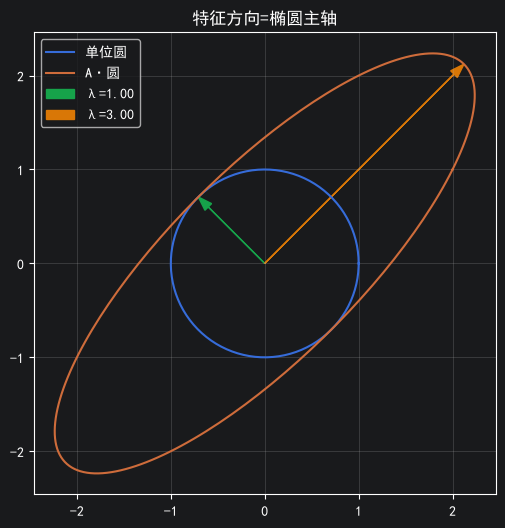

In [8]:
A = np.array([[2.0, 1.0], [1.0, 2.0]])
w, V = np.linalg.eigh(A)
theta = np.linspace(0, 2 * np.pi, 200)
circle = np.vstack([np.cos(theta), np.sin(theta)])
ellipsis = A @ circle

# 可视化
plt.figure(figsize=(6, 6))
plt.plot(circle[0], circle[1], label='单位圆')
plt.plot(ellipsis[0], ellipsis[1], label='A·圆')
for i in range(2):
    v = V[:, i] * w[i]
    plt.arrow(0, 0, v[0], v[1], head_width=0.1, color=['#16a34a', '#d97706'][i], length_includes_head=True,
              label=f'λ={w[i]:.2f}')

plt.gca().set_aspect('equal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title('特征方向=椭圆主轴')


In [7]:
for s in [1.0, 0.5, 0.1]:
    H = np.diag([2.0, 2.0 * s])
    w = np.linalg.eigvalsh(H)

print(f'曲率相关 s={s}: lamda={w},cond={w.max() / w.min():.4f},λv={w[i] * v}')

B = np.array([[1.0, 2.0], [2.0, 4.0]])
print('det', np.linalg.det(B), '特征值', np.linalg.eigvals(B))

曲率相关 s=0.1: lamda=[0.2 2. ],cond=10.0000,λv=[4.24264069 4.24264069]
det 0.0 特征值 [0.+0.j 5.+0.j]


In [ ]:
# 课堂问题:
# # 1.特征值可以为0吗?
# 答:可以,特征值为0,意味着矩阵不可逆,即行列式为零,对应方向的向量被压扁到了原点
# - 完全可以为0
#     -
# # 2.特征向量一定是单位向量吗?
# 不一定,特征向量可以任意缩放,可以是单位向量也可以
# 之锁定方向不锁定长度,返回的是单位向量,只是方便计算,方向是特征向量的灵魂,长度只是外衣
# # 3. 所有的矩阵都有特征值吗
# 不一定,在实数范围内所有的矩阵不是都有是对成特征值,
# 这一点常常,最和实数范围内偶数,旋转缩放,诗对称矩阵一定拥有是对称值,这是协方差矩阵,是对成矩阵一定有实数解
# # 4. 特征值分解和svd的区别?
# 特征值分解只适用于方阵,svd是特征值的推广
# 是从方正走向一般的普适性推广,特征值分解要求矩阵呢个必须是一个方正,描述的是一个线性变换,在自己特征方向的绳索,在显示中很多的矩阵非方正,svd将任意矩阵拆UV 对角奇异值矩阵,SVD的奇异值At*A 特征值的平方根,svd三视图投影
# # 5. 为什么PCA要用协方差矩阵？
# #     - 协方差矩阵是对称的，特征向量是正交的，可以得到一组正交基，协方差矩阵的特征值反映了数据在其对应方向上的方差大小。
# pca 协方差矩阵找一组正交方向,加上数据已经中心化(均值为0),协防差居正是是对成矩阵,可以获得实数解,Gram-Schmidt正交化,=数据投影等于V特征值越大,方向上承载的信息越多,对协方差举报v正特征分解,排序,去前k的特征矩阵,让几何直觉于代数求解联系到一起

工具加载成功


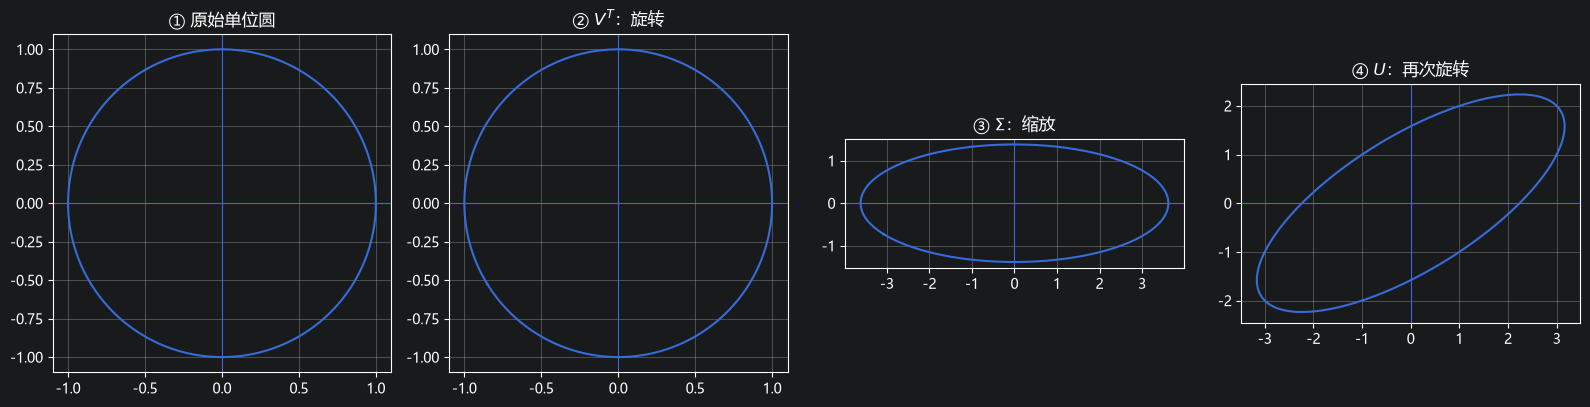

A =
[[3. 1.]
 [1. 2.]]

U =
[[-0.85065081 -0.52573111]
 [-0.52573111  0.85065081]]

Σ =
[[3.61803399 0.        ]
 [0.         1.38196601]]

Vᵀ =
[[-0.85065081 -0.52573111]
 [-0.52573111  0.85065081]]

验证 A ≈ UΣVᵀ：
[[3. 1.]
 [1. 2.]]


In [26]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False
print('工具加载成功')


def draw_svd(A):
    U, S, Vt = np.linalg.svd(A)

    # Sigma 矩阵
    Sigma = np.diag(S)

    # 创建单位圆
    theta = np.linspace(0, 2 * np.pi, 200)
    circle = np.vstack([np.cos(theta), np.sin(theta)])

    # 第一次旋转
    step1 = Vt @ circle
    # 第二次缩放
    step2 = Sigma @ step1
    # 第三次旋转
    step3 = U @ step2

    result = A @ circle

    # 绘图
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    # 原始单位圆
    axes[0].plot(circle[0], circle[1])
    axes[0].set_title("① 原始单位圆")
    # V^T
    axes[1].plot(step1[0], step1[1])
    axes[1].set_title(r"② $V^T$：旋转")
    #  # Sigma
    axes[2].plot(step2[0], step2[1])
    axes[2].set_title(r"③ $\Sigma$：缩放")
    # U
    axes[3].plot(step3[0], step3[1])
    axes[3].set_title(r"④ $U$：再次旋转")

      # 坐标轴
    for ax in axes:
        ax.axhline(0, linewidth=0.8)
        ax.axvline(0, linewidth=0.8)
        ax.set_aspect("equal")
        ax.grid(True)

    plt.tight_layout()
    plt.show()


    # 5. 输出 SVD 结果

    print("A =")
    print(A)

    print("\nU =")
    print(U)

    print("\nΣ =")
    print(Sigma)

    print("\nVᵀ =")
    print(Vt)

    print("\n验证 A ≈ UΣVᵀ：")
    print(U @ Sigma @ Vt)

A = np.array([
    [3, 1],
    [1, 2]
], dtype=float)

draw_svd(A)
